# Лабораторная работа 2. Рекомендательные системы

**Датасет:** конкурс ODS.ai [«По страницам»](https://ods.ai/competitions/nto25-26-hack/dataset), архив `participants.zip`, файл `participants/data/interactions.csv`. Это данные о взаимодействиях пользователей книжной платформы с изданиями. Датасет не относится к Kaggle или MovieLens.

**Задача:** для пользователя рекомендовать **ранее неизвестные ему издания, которые он прочитает в будущем**. Целевая переменная — факт прочтения издания (`event_type = 2`). Событие `event_type = 1` означает добавление в список планов; оно не считается прочтением.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors

paths = [Path('interactions(1).csv'), Path('interactions.csv'), Path('data/interactions.csv')]
path = next((p for p in paths if p.exists()), None)
if path is None:
    raise FileNotFoundError('Поместите interactions(1).csv рядом с ноутбуком или используйте data/interactions.csv')

df = pd.read_csv(path, parse_dates=['event_ts'])
print('Размер:', df.shape)
display(df.head())
print(df.dtypes)

Размер: (231210, 5)


,user_id,edition_id,event_type,rating,event_ts
0,560,1012411658,2,6.0,2024-12-24 19:02:14
1,560,1008465904,2,6.0,2025-01-10 19:18:04
2,560,1001243738,2,10.0,2025-01-25 11:28:11
3,560,1009492501,2,8.0,2025-01-25 11:28:42
4,560,1000118974,2,8.0,2025-03-10 18:14:17


user_id                int64
edition_id             int64
event_type             int64
rating               float64
event_ts      datetime64[ns]
dtype: object


## 1. Разведочный анализ и качество данных

Каждая строка описывает событие: пользователь `user_id`, издание `edition_id`, тип события `event_type`, оценка `rating` и время `event_ts`. Оценка может отсутствовать; она не используется при обучении моделей. Сначала проверим пропуски, дубликаты и допустимые значения.

In [2]:
quality = pd.DataFrame({
    'Пропусков': df.isna().sum(),
    'Доля пропусков, %': (df.isna().mean() * 100).round(2),
    'Уникальных значений': df.nunique(dropna=True)
})
display(quality)
print('Полные дубликаты:', df.duplicated().sum())
print('Повторные пары пользователь–издание:', df.duplicated(['user_id', 'edition_id']).sum())
print('Типы событий:', df['event_type'].value_counts().sort_index().to_dict())
print('Оценки вне диапазона 1–10:', df['rating'].notna().sum() - df['rating'].between(1, 10).sum())
print('Неверные типы событий:', (~df['event_type'].isin([1, 2])).sum())
print('Период:', df['event_ts'].min(), '—', df['event_ts'].max())

print('Пропуски оценок по типам событий:')
display(df.groupby('event_type')['rating'].apply(lambda x: x.isna().sum()).rename('Пропусков').to_frame())

,Пропусков,"Доля пропусков, %",Уникальных значений
user_id,0,0.00,5067
edition_id,0,0.00,74528
event_type,0,0.00,2
rating,105841,45.78,10
event_ts,0,0.00,228212


Полные дубликаты: 0
Повторные пары пользователь–издание: 172
Типы событий: {1: 84551, 2: 146659}
Оценки вне диапазона 1–10: 0
Неверные типы событий: 0
Период: 2024-10-14 18:48:56 — 2025-04-12 12:44:23
Пропуски оценок по типам событий:


,Пропусков
event_type,
1,84551
2,21290


In [3]:
user_counts = df.groupby('user_id').size()
item_counts = df.groupby('edition_id').size()
print('Пользователей:', df['user_id'].nunique())
print('Изданий:', df['edition_id'].nunique())
print('Событий:', len(df))
print('События на пользователя:')
display(user_counts.describe().round(1).to_frame('Количество'))
print('События на издание:')
display(item_counts.describe().round(1).to_frame('Количество'))
print('Оценки прочитанных изданий:')
display(df.loc[df['event_type'] == 2, 'rating'].describe().round(1).to_frame('Оценка'))

print('99-й процентиль событий на пользователя:', user_counts.quantile(.99))
print('99-й процентиль событий на издание:', item_counts.quantile(.99))

Пользователей: 5067
Изданий: 74528
Событий: 231210
События на пользователя:


,Количество
count,5067.0
mean,45.6
std,46.3
min,5.0
25%,16.0
50%,30.0
75%,57.0
max,290.0


События на издание:


,Количество
count,74528.0
mean,3.1
std,8.2
min,1.0
25%,1.0
50%,1.0
75%,2.0
max,378.0


Оценки прочитанных изданий:


,Оценка
count,125369.0
mean,8.3
std,1.8
min,1.0
25%,8.0
50%,8.0
75%,10.0
max,10.0


99-й процентиль событий на пользователя: 234.34000000000015
99-й процентиль событий на издание: 33.0


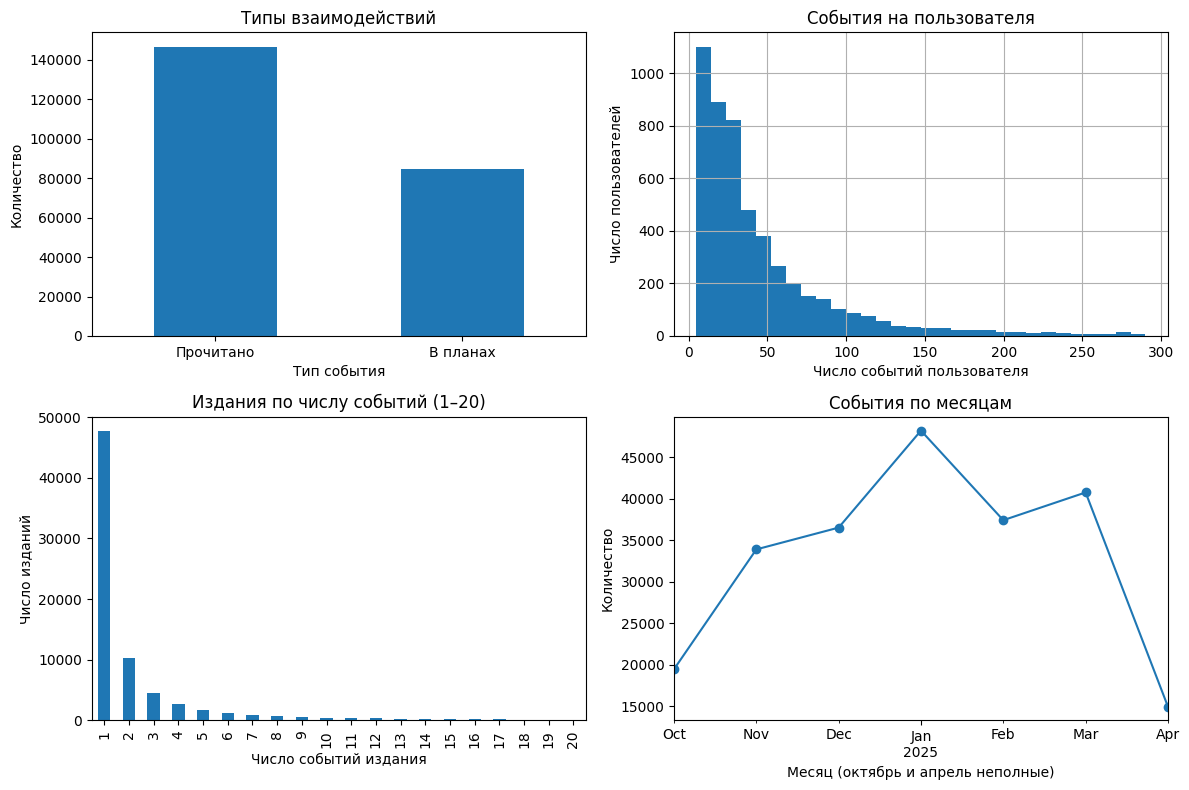

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
df['event_type'].map({1: 'В планах', 2: 'Прочитано'}).value_counts().plot.bar(ax=ax[0, 0], rot=0)
ax[0, 0].set_title('Типы взаимодействий')
user_counts.hist(bins=30, ax=ax[0, 1])
ax[0, 1].set_title('События на пользователя')
item_counts.value_counts().reindex(range(1, 21), fill_value=0).plot.bar(ax=ax[1, 0])
ax[1, 0].set_title('Издания по числу событий (1–20)')
monthly = df.set_index('event_ts').resample('MS').size()
monthly.plot(ax=ax[1, 1], marker='o')
ax[1, 1].set_title('События по месяцам')
for a in ax.flat:
    a.set_ylabel('Количество')
ax[0, 0].set_xlabel('Тип события')
ax[0, 1].set_xlabel('Число событий пользователя')
ax[0, 1].set_ylabel('Число пользователей')
ax[1, 0].set_xlabel('Число событий издания')
ax[1, 0].set_ylabel('Число изданий')
ax[1, 1].set_xlabel('Месяц (октябрь и апрель неполные)')
plt.tight_layout()
plt.show()

**Отчёт по качеству данных.** В идентификаторах, типе события и дате пропусков нет. В `rating` отсутствует 105 841 значение: 84 551 относятся к книгам «в планах», ещё 21 290 — к событиям прочтения. Оценка не нужна для выбранной цели, поэтому пропуски не заполняем. Полных дубликатов нет. Повторных пар пользователь–издание — 172; они могут отражать последовательные события, поэтому исходные строки сохраняем, а при построении матрицы сводим повторные прочтения к одному бинарному значению. Неверных типов события и оценок вне диапазона 1–10 нет.

**Распределения и выбросы.** Половина изданий имеет только одно событие; у пользователей медиана — 30 событий. 99-й процентиль активности пользователя составляет около 234 событий, максимум — 290; для изданий 99-й процентиль равен 33, максимум — 378. Такие значения заметно выше типичных, но являются допустимой активностью и не удаляются. Среди полных месяцев максимум событий приходится на январь. Октябрь начинается 14-го числа, а апрель заканчивается 12-го, поэтому меньшие месячные суммы не доказывают падение активности. Временное разделение выбрано, чтобы проверять прогноз будущих прочтений по прошлой истории. Разреженность обучающей матрицы прочтений составляет около 99,95%, поэтому используются разреженные методы.

**Интерпретация остальных графиков.** Прочтений больше, чем добавлений в планы. Распределение активности пользователей имеет длинный правый хвост: небольшая часть пользователей существенно активнее большинства. Большинство изданий имеют мало взаимодействий, что затрудняет поиск похожих предпочтений. 

## 2. Обучающая и тестовая выборки

Последние 20% событий по времени оставляем для тестирования. Модели видят только события до временной границы. Релевантными считаем прочитанные в тестовом периоде **новые для пользователя** издания. Оцениваем пользователей, у которых до границы было хотя бы одно прочтение. Новые для всей системы издания остаются в знаменателе Recall@10: методы на взаимодействиях не смогут их предложить, и это честно отражает задачу холодного старта. Рекомендации уже виденных в обучении изданий исключаются.

**Границы задачи.** Издание, уже добавленное в планы, тоже считается известным пользователю; прогноз перехода из планов в прочтение не рассматривается. Метрики относятся к пользователям с прочтением в train и хотя бы одним новым прочтением в test. Новые пользователи и пользователи без целевых тестовых событий не оцениваются. Это офлайн-оценка наблюдаемых прочтений: отсутствие прочтения не обязательно означает отсутствие интереса.

In [5]:
cutoff = df['event_ts'].quantile(0.8)
train = df.loc[df['event_ts'] <= cutoff].copy()
test = df.loc[df['event_ts'] > cutoff].copy()
train_reads = train.loc[train['event_type'] == 2, ['user_id', 'edition_id']].drop_duplicates()
seen = train[['user_id', 'edition_id']].drop_duplicates()
test_reads = test.loc[test['event_type'] == 2, ['user_id', 'edition_id']].drop_duplicates()
train_pairs = pd.MultiIndex.from_frame(seen)
test_reads = test_reads.loc[~pd.MultiIndex.from_frame(test_reads).isin(train_pairs)]
test_reads = test_reads.loc[test_reads['user_id'].isin(train_reads['user_id'])]

truth = test_reads.groupby('user_id')['edition_id'].agg(set).to_dict()
seen_by_user = seen.groupby('user_id')['edition_id'].agg(set).to_dict()
users = train_reads['user_id'].unique()
items = train_reads['edition_id'].unique()
user_to_idx = {v: k for k, v in enumerate(users)}
item_to_idx = {v: k for k, v in enumerate(items)}
rows = train_reads['user_id'].map(user_to_idx).to_numpy()
cols = train_reads['edition_id'].map(item_to_idx).to_numpy()
X = csr_matrix((np.ones(len(rows), dtype=np.float32), (rows, cols)),
               shape=(len(users), len(items)))

display(pd.DataFrame({'Событий': [len(train), len(test)],
                      'Начало': [train['event_ts'].min(), test['event_ts'].min()],
                      'Конец': [train['event_ts'].max(), test['event_ts'].max()]},
                     index=['Обучение', 'Тест']))
print('Матрица пользователей × издания:', X.shape, 'ненулевых элементов:', X.nnz)
print('Пользователей с целевыми прочтениями:', len(truth))
print('Новых прочтений в тесте:', len(test_reads))
print('Из них ранее неизвестных системе изданий:', (~test_reads['edition_id'].isin(items)).sum())

print('Разреженность матрицы, %:', round(100 * (1 - X.nnz / (X.shape[0] * X.shape[1])), 4))
print('Доля неизвестных каталогу целевых прочтений, %:', round(100 * (~test_reads['edition_id'].isin(items)).mean(), 2))
print('Пользователей с прочтениями в test до фильтрации:', test.loc[test['event_type'] == 2, 'user_id'].nunique())
assert train['event_ts'].max() < test['event_ts'].min()
assert not pd.MultiIndex.from_frame(test_reads).isin(train_pairs).any()

,Событий,Начало,Конец
Обучение,184968,2024-10-14 18:48:56,2025-03-08 14:32:42
Тест,46242,2025-03-08 14:33:37,2025-04-12 12:44:23


Матрица пользователей × издания: (4884, 47486) ненулевых элементов: 116293
Пользователей с целевыми прочтениями: 4271
Новых прочтений в тесте: 27377
Из них ранее неизвестных системе изданий: 8411
Разреженность матрицы, %: 99.9499
Доля неизвестных каталогу целевых прочтений, %: 30.72
Пользователей с прочтениями в test до фильтрации: 4407


## 3. Методы формирования рекомендаций

Все методы предлагают 10 изданий из обучающего каталога и исключают издания, которые пользователь уже добавлял в планы или читал до тестового периода.

1. **MostPop:** сортирует издания по числу прочитавших пользователей. Общий список для всех пользователей.
2. **UserKNN:** ищет 40 пользователей с похожей историей прочтений по косинусному расстоянию. Кандидаты получают сумму сходств соседей, которые их прочли; пустые позиции заполняются популярными изданиями.
3. **SVD:** представляет разреженную матрицу прочтений 32 скрытыми факторами и ранжирует по скалярному произведению представлений пользователя и издания. Используется `TruncatedSVD` из scikit-learn.

Матрицу не переводим целиком в плотный формат.

**Обоснование выбора.** MostPop — простой базовый уровень: он показывает, полезнее ли персонализация общей популярности. UserKNN напрямую использует общие прочтения пользователей и подходит для бинарной истории взаимодействий. SVD выделяет скрытые предпочтения, приближая матрицу прочтений произведением низкоразмерных матриц; это позволяет сравнить соседский и факторизационный подходы. `TruncatedSVD` применяется к бинарной матрице без центрирования, а не к прогнозу числовых оценок. 40 соседей и 32 фактора — фиксированные начальные параметры; их оптимальность не утверждается, подбор на тесте не проводится.

Для UserKNN оценка кандидата равна сумме косинусных сходств с соседями, прочитавшими издание. Добавка `1e-6 * popularity` разрешает равенства и даёт популярные рекомендации кандидатам с нулевой соседской оценкой. При равных итоговых оценках порядок изданий не фиксируется. MostPop прост, но не учитывает личный вкус; UserKNN зависит от пересечений историй; SVD при малой размерности может терять редкие предпочтения. Все три метода ограничены каталогом прочтений train.

Если несколько пользователей имеют одинаковую косинусную близость на границе 40 соседей, состав выбранных соседей может зависеть от версии библиотек. Это может давать небольшие различия итоговых метрик. Итоговая таблица всегда отражает текущий запуск.

In [6]:
K = 10
popularity = np.asarray(X.sum(axis=0)).ravel()
popular_order = np.argsort(-popularity, kind='stable')

knn = NearestNeighbors(n_neighbors=41, metric='cosine', algorithm='brute', n_jobs=-1)
knn.fit(X)

distances, neighbors = knn.kneighbors(X, return_distance=True)
svd = TruncatedSVD(n_components=32, random_state=42)
user_factors = svd.fit_transform(X)
item_factors = svd.components_
print('Модели обучены. Объяснённая дисперсия SVD:', round(svd.explained_variance_ratio_.sum(), 3))

Модели обучены. Объяснённая дисперсия SVD: 0.068


In [7]:
def top10(scores, user_id):
    scores = np.asarray(scores, dtype=np.float64).copy()
    for edition_id in seen_by_user.get(user_id, set()):
        index = item_to_idx.get(edition_id)
        if index is not None:
            scores[index] = -np.inf
    top = np.argpartition(scores, -K)[-K:]
    top = top[np.argsort(-scores[top])]
    return items[top].tolist()

recommendations = {'MostPop': {}, 'UserKNN': {}, 'SVD': {}}
for user_id in truth:
    u = user_to_idx[user_id]
    recommendations['MostPop'][user_id] = top10(popularity, user_id)

    neighbor_ids = neighbors[u]
    similarities = 1 - distances[u]
    use = neighbor_ids != u
    neighbor_ids = neighbor_ids[use][:40]
    similarities = similarities[use][:40]
    scores_knn = np.asarray(X[neighbor_ids].T.dot(similarities)).ravel()
    # Малый популярностный приоритет для равенств и отсутствующих сигналов.
    scores_knn += 1e-6 * popularity
    recommendations['UserKNN'][user_id] = top10(scores_knn, user_id)

    scores_svd = user_factors[u] @ item_factors
    recommendations['SVD'][user_id] = top10(scores_svd, user_id)

print('Списков рекомендаций на метод:', len(truth))

for method, rec_lists in recommendations.items():
    assert set(rec_lists) == set(truth)
    for user_id, rec in rec_lists.items():
        assert len(rec) == K and len(set(rec)) == K
        assert set(rec).issubset(item_to_idx)
        assert not set(rec) & seen_by_user[user_id]
print('Проверено: по 10 уникальных изданий, без уже известных, одинаковые пользователи у всех методов.')

Списков рекомендаций на метод: 4271
Проверено: по 10 уникальных изданий, без уже известных, одинаковые пользователи у всех методов.


## 4. Метрики качества на тесте

Для каждого пользователя считаем **Precision@10** (долю релевантных среди десяти рекомендаций), **Recall@10** (долю найденных изданий среди его новых прочтений), **NDCG@10** (учитывает позиции: попадание выше ценится сильнее) и **Novelty@10** (среднюю неожиданность через обратную популярность издания в обучении). Усредняем метрики по пользователям. Дополнительно считаем **Coverage@10**: долю обучающего каталога, встретившуюся хотя бы в одной выдаче. Выше значение каждой из этих метрик — лучше, но новизну и охват нужно рассматривать вместе с точностью.

Поскольку ранее неизвестное издание не входит в каталог моделей, Recall@10 учитывает его как непрогнозируемое релевантное издание. Формулы:

$\mathrm{Precision@10}=|R_u\cap T_u|/10$, $\mathrm{Recall@10}=|R_u\cap T_u|/|T_u|$;
$\mathrm{DCG@10}=\sum_{j=1}^{10}\mathbf{1}[r_j\in T_u]/\log_2(j+1)$, $\mathrm{NDCG@10}=\mathrm{DCG@10}/\mathrm{IDCG@10}$;
$\mathrm{Novelty@10}=\mathrm{mean}_{r\in R_u}[-\log_2(p_r/N)]$, где $p_r$ — число пользователей, прочитавших издание в обучении, $N$ — число обучающих пользователей.

Здесь $R_u$ — упорядоченные рекомендации, $T_u$ — множество новых прочтений пользователя в test; $\mathrm{IDCG@10}=\sum_{j=1}^{\min(10,|T_u|)}1/\log_2(j+1)$. $\mathrm{Coverage@10}=|\bigcup_u R_u|/|I_{train}|$. Precision, Recall, NDCG и Coverage лежат в диапазоне [0, 1]; Novelty измеряется в битах. Новизна по обратной популярности не равнозначна персональной неожиданности или разнообразию. Неизвестные каталогу релевантные издания остаются в знаменателях Recall и идеальном DCG, поэтому ограничивают обе метрики. Результаты усредняются по пользователям: каждый пользователь имеет одинаковый вес независимо от числа прочтений.

In [8]:
def evaluate(rec_lists):
    precision, recall, ndcg, novelty = [], [], [], []
    all_recommended = set()
    for user_id, recommended in rec_lists.items():
        relevant = truth[user_id]
        hits = np.array([edition_id in relevant for edition_id in recommended], dtype=float)
        precision.append(hits.sum() / K)
        recall.append(hits.sum() / len(relevant))
        discount = 1 / np.log2(np.arange(2, K + 2))
        ideal = discount[:min(len(relevant), K)].sum()
        ndcg.append((hits * discount).sum() / ideal)
        indices = [item_to_idx[edition_id] for edition_id in recommended]
        novelty.append(np.mean(-np.log2(popularity[indices] / len(users))))
        all_recommended.update(recommended)
    return {'Precision@10': np.mean(precision), 'Recall@10': np.mean(recall),
            'NDCG@10': np.mean(ndcg), 'Novelty@10': np.mean(novelty),
            'Coverage@10': len(all_recommended) / len(items)}

results = pd.DataFrame({name: evaluate(rec) for name, rec in recommendations.items()}).T
results.index.name = 'Метод'
display(results.round(4))

,Precision@10,Recall@10,NDCG@10,Novelty@10,Coverage@10
Метод,,,,,
MostPop,0.0090,0.0171,0.0148,4.8190,0.0005
UserKNN,0.0186,0.0389,0.0385,6.8699,0.0954
SVD,0.0137,0.0276,0.0267,5.9743,0.0111


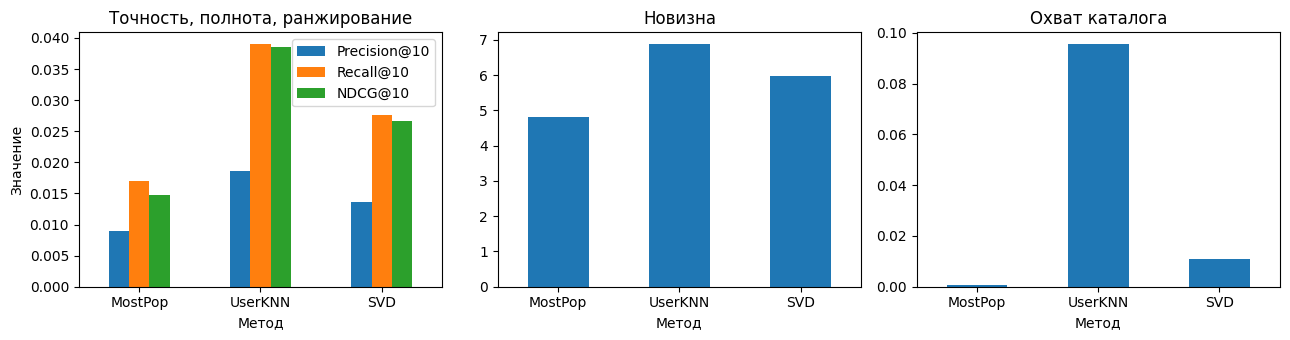

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
results[['Precision@10', 'Recall@10', 'NDCG@10']].plot.bar(ax=axes[0], rot=0)
axes[0].set_title('Точность, полнота, ранжирование')
axes[0].set_ylabel('Значение')
results['Novelty@10'].plot.bar(ax=axes[1], rot=0, title='Новизна')
results['Coverage@10'].plot.bar(ax=axes[2], rot=0, title='Охват каталога')
plt.tight_layout()
plt.show()

In [10]:
print(f'Оценено {len(truth):,} пользователей, {len(test_reads):,} новых прочтений.')
print(f'Недоступны каталогу моделей {(~test_reads.edition_id.isin(items)).sum():,} целевых прочтений.')
print('Практический смысл метрик:')
for name, row in results.iterrows():
    print(f"{name}: {row['Precision@10'] * K:.3f} попадания на список из 10; "
          f"найдено в среднем {row['Recall@10']:.2%} целевых прочтений пользователя; "
          f"охват каталога {row['Coverage@10']:.2%}.")
print(f"Recall UserKNN / MostPop: {results.loc['UserKNN', 'Recall@10'] / results.loc['MostPop', 'Recall@10']:.2f} раза")


Оценено 4,271 пользователей, 27,377 новых прочтений.
Недоступны каталогу моделей 8,411 целевых прочтений.
Практический смысл метрик:
MostPop: 0.090 попадания на список из 10; найдено в среднем 1.71% целевых прочтений пользователя; охват каталога 0.05%.
UserKNN: 0.186 попадания на список из 10; найдено в среднем 3.89% целевых прочтений пользователя; охват каталога 9.54%.
SVD: 0.137 попадания на список из 10; найдено в среднем 2.76% целевых прочтений пользователя; охват каталога 1.11%.
Recall UserKNN / MostPop: 2.28 раза


## 5. Сравнение методов и предложения по улучшению

Численные результаты приведены в таблице `results` и на графиках выше. Таблица рассчитывается из рекомендаций при каждом запуске; отдельные вручную скопированные значения не используются.

**Сравнение.** UserKNN лидирует по пяти выбранным метрикам в данном эксперименте: похожие истории пользователей дают больше попаданий и расширяют набор рекомендуемых изданий. SVD улучшает точность и ранжирование относительно MostPop, но уступает UserKNN. Это результат для фиксированных параметров и выбранной границы, а не доказательство общего превосходства алгоритма. MostPop выдаёт преимущественно одни и те же популярные издания, поэтому его новизна и охват ниже. Рост Novelty и Coverage полезен здесь вместе с ростом точности; сам по себе показ редких книг не означает хороших рекомендаций.

**Ограничения.** Низкие абсолютные значения точности согласуются с разреженностью матрицы, большим каталогом и существенной долей неизвестных каталогу изданий в test. Эти факторы — возможные объяснения; их отдельный вклад не измерялся. Часть будущих прочтений уже известных пользователю книг исключена согласно цели. Результаты не характеризуют качество для новых пользователей. Оценки прочтений не учитываются: модель предсказывает факт прочтения, а не удовлетворённость книгой. Доверительные интервалы и статистическая значимость различий не оценивались.

**Предложения по улучшению.**
1. Использовать метаданные из `editions.csv` (автора, описание и другие доступные признаки) для содержательных рекомендаций. Это позволит предлагать издания без прочтений в train и уменьшит проблему холодного старта каталога.
2. Выделить хронологическую валидационную часть внутри train, подобрать число соседей и размерность SVD по NDCG@10, затем переобучить на всём train. Тест использовать только для итоговой оценки.
3. Включить добавления в планы как более слабый положительный сигнал; вес подобрать на валидации. При этом известные пользователю издания по-прежнему исключать из выдачи согласно выбранной цели.

**Итог.** Построена система рекомендаций новых для пользователя изданий по истории прочтений. Проведён EDA и отчёт по качеству, выполнено временное разделение, реализованы три метода разных семейств и рассчитаны пять метрик на общей тестовой выборке. Лучший из испытанных методов — UserKNN. Основные направления улучшения — метаданные для холодного старта и настройка методов на отдельной валидации.
